# RollbackLROnPlateau: An Experimental Investigation of Training Recovery

This notebook investigates whether restoring the best model parameters before reducing the learning rate can alter the training trajectory after validation loss plateaus.

Three training strategies are evaluated across repeated runs:

1. Rollback with optimizer state reset
2. Rollback with optimizer state retained
3. Standard `ReduceLROnPlateau`

The experiments record training trajectories, validation loss, learning-rate changes, rollback events, and final outcomes for analysis.

## 1. Research Question

When validation loss stops improving, does returning to the best previously observed model state before reducing the learning rate lead to a different training trajectory?

Additionally, does resetting the optimizer state after rollback produce different behavior from retaining it?

## 2. Hypothesis

If training moves away from a previously better region of the parameter space, restoring the best model state before reducing the learning rate may allow optimization to continue from a more favorable point.

Because AdamW maintains internal optimizer state, resetting or retaining that state may lead to different subsequent trajectories.

This investigation tests these behaviors empirically rather than assuming that rollback will universally improve training.

## 3. Experimental Setup

| Component | Configuration |
|---|---|
| Dataset | Fashion-MNIST |
| Task | 10-class image classification |
| Model | `784 → 512 → 128 → 64 → 10` |
| Activation | GELU |
| Normalization | BatchNorm |
| Regularization | Dropout |
| Loss | CrossEntropyLoss |
| Optimizer | AdamW |
| Initial Learning Rate | `5e-3` |
| Runs per configuration | 10 |

The model architecture and data pipeline are kept fixed across experiments. The scheduler configuration is the primary experimental variable.

## Imports and reproducibility information

In [4]:
import os
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
)

### Environment

The experiments are executed locally using PyTorch with GPU acceleration when available.

The purpose of recording the environment is to make the experiment easier to reproduce and interpret.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 5. Dataset Preparation

The dataset is prepared for a 10-class classification task. Images are converted into the input representation required by the neural network.

In [6]:
train = pd.read_csv('dataset/fashion-mnist_train.csv')
test = pd.read_csv('dataset/fashion-mnist_test.csv')

In [7]:
train_labels = train.iloc[:,0]
test_labels = test.iloc[:,0]

x_train = train.iloc[:,1:]
x_test = test.iloc[:,1:]

In [8]:
print(f'training data shape: {x_train.shape}')
print(f'test data shape: {x_test.shape}')

training data shape: (60000, 784)
test data shape: (10000, 784)


In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

### train-val-split

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, train_labels, test_size=0.2, random_state=42)

### Scaling and normalisation

In [11]:
from sklearn.preprocessing import StandardScaler

# scaling first by dividibg by 255 as pixel values lie btw 0 to 255 generally
x_train = x_train/255
x_val = x_val/255
x_test = x_test/255


# Normalizing all features using standard scalar
ss = StandardScaler()
ss.fit_transform(x_train)
ss.transform(x_val)
ss.transform(x_test)

array([[-0.00960813, -0.02239017, -0.02829561, ..., -0.15932115,
        -0.09217697, -0.0315794 ],
       [-0.00960813, -0.02239017, -0.02829561, ..., -0.15932115,
        -0.09217697, -0.0315794 ],
       [-0.00960813, -0.02239017, -0.02829561, ..., -0.15932115,
        -0.09217697, -0.0315794 ],
       ...,
       [-0.00960813, -0.02239017, -0.02829561, ..., -0.15932115,
         0.0167578 , -0.0315794 ],
       [-0.00960813,  3.34666357,  2.21664533, ..., -0.15932115,
        -0.09217697, -0.0315794 ],
       [-0.00960813, -0.02239017, -0.02829561, ..., -0.15932115,
        -0.09217697, -0.0315794 ]], shape=(10000, 784))

In [12]:
x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor  = torch.tensor(test_labels.values, dtype=torch.long)

In [13]:
print(x_train_tensor.dtype)
print(x_train_tensor.shape)

torch.float32
torch.Size([48000, 784])


In [14]:
print(y_train_tensor.dtype)
print(y_train_tensor.shape)

torch.int64
torch.Size([48000])


### Dataloader

In [15]:
from torch.utils.data import DataLoader, Dataset

class FashionDataset(Dataset):
    
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, index):
        return self.features[index], self.labels[index]
        

train_dataset = FashionDataset(x_train_tensor, y_train_tensor)
test_dataset = FashionDataset(x_test_tensor, y_test_tensor)
val_dataset = FashionDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=250, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=250, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=250, shuffle=False)


In [16]:
x_batch, y_batch = next(iter(train_loader))

print(x_batch.shape)
print(y_batch.shape)
print(x_batch.device)
print(y_batch.device)

torch.Size([250, 784])
torch.Size([250])
cpu
cpu


## 6. Model Architecture

The model used for all experiments is a fixed multilayer perceptron.

The architecture is intentionally kept unchanged across configurations so that the experiment focuses on training dynamics rather than architectural differences.

In [17]:
import torch
import torch.nn as nn


class FashionANN(nn.Module):

    def __init__(self, num_features=784, num_classes=10):
        super().__init__()

        self.network = nn.Sequential(

            # Layer 1
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.30),

            # Layer 2
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.25),

            # Layer 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.20),

            # Output layer
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

## 7. Training Configuration

The following parameters are shared across the experiments unless explicitly stated otherwise.

Scheduler-specific parameters will be defined with each experiment.

In [18]:
TRAIN_CONFIG = {
    "num_epochs": 100,
    "early_stopping_patience": 15,
    "initial_lr": 5e-3,
    "weight_decay": 1e-3,
}

In [19]:
import torch
import copy


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,

    scheduler_type="plateau",   # "plateau" or "rollback"

    num_epochs=100,

    factor=0.25,
    patience=3,
    threshold=1e-4,
    min_lr=1e-6,

    max_rollbacks=3,
    reset_optimizer=True,

    early_stopping_patience=15,

    checkpoint_path="best_model.pth"
):

    model = model.to(device)

    # ==================================================
    # Scheduler
    # ==================================================

    if scheduler_type == "plateau":

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=factor,
            patience=patience,
            threshold=threshold,
            min_lr=min_lr
        )

    elif scheduler_type == "rollback":

        scheduler = RollbackLROnPlateau(
            model=model,
            optimizer=optimizer,
            factor=factor,
            patience=patience,
            threshold=threshold,
            min_lr=min_lr,
            max_rollbacks=max_rollbacks,
            reset_optimizer=reset_optimizer
        )

    else:
        raise ValueError(
            "scheduler_type must be 'plateau' or 'rollback'"
        )

    # ==================================================
    # History
    # ==================================================

    train_losses = []
    val_losses = []
    lr_history = []
    rollback_epochs = []
    lr_change_epochs = []

    # ==================================================
    # Early stopping
    # ==================================================

    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    best_model_state = None

    # ==================================================
    # Training
    # ==================================================

    print("=" * 75)
    print(f"Training with: {scheduler_type.upper()}")
    print("=" * 75)

    for epoch in range(num_epochs):

        # --------------------------------------------------
        # TRAINING
        # --------------------------------------------------

        model.train()

        running_train_loss = 0.0
        train_samples = 0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(x_batch)

            loss = criterion(
                logits,
                y_batch
            )

            loss.backward()

            optimizer.step()

            batch_size = x_batch.size(0)

            running_train_loss += (
                loss.item() * batch_size
            )

            train_samples += batch_size

        train_loss = (
            running_train_loss / train_samples
        )

        # --------------------------------------------------
        # VALIDATION
        # --------------------------------------------------

        model.eval()

        running_val_loss = 0.0
        val_samples = 0

        with torch.no_grad():

            for x_batch, y_batch in val_loader:

                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(x_batch)

                loss = criterion(
                    logits,
                    y_batch
                )

                batch_size = x_batch.size(0)

                running_val_loss += (
                    loss.item() * batch_size
                )

                val_samples += batch_size

        val_loss = (
            running_val_loss / val_samples
        )

        # --------------------------------------------------
        # CHECK IMPROVEMENT
        # --------------------------------------------------

        improved = (
            val_loss
            < best_val_loss - threshold
        )

        if improved:

            best_val_loss = val_loss
            best_epoch = epoch

            epochs_without_improvement = 0

            # Save best weights for early stopping
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            epochs_without_improvement += 1

        # --------------------------------------------------
        # SCHEDULER
        # --------------------------------------------------

        rollback = False
        
        previous_lr = optimizer.param_groups[0]["lr"]
        
        if scheduler_type == "plateau":
        
            scheduler.step(val_loss)
        
        elif scheduler_type == "rollback":
        
            scheduler_result = scheduler.step(
                val_loss=val_loss,
                epoch=epoch
            )
        
            rollback = scheduler_result["rollback"]
        
            if rollback:
                rollback_epochs.append(epoch)
        
                # Restart early-stopping patience after rollback
                epochs_without_improvement = 0
        
        current_lr = optimizer.param_groups[0]["lr"]
        
        lr_changed = current_lr != previous_lr
        if lr_changed:
            lr_change_epochs.append(epoch)
        # --------------------------------------------------
        # SAVE HISTORY
        # --------------------------------------------------

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        lr_history.append(current_lr)

        # --------------------------------------------------
        # OUTPUT
        # --------------------------------------------------

        if improved:

            status = "★ BEST"

        elif rollback:

            status = "↻ ROLLBACK"

        elif lr_changed:

            status = "↓ LR"

        else:

            status = ""

        print(
            f"Epoch [{epoch + 1:03d}/{num_epochs}] "
            f"Train: {train_loss:.5f} | "
            f"Val: {val_loss:.5f} | "
            f"LR: {current_lr:.2e} | "
            f"No Improve: "
            f"{epochs_without_improvement:02d} "
            f"{status}"
        )

        # --------------------------------------------------
        # EARLY STOPPING
        # --------------------------------------------------

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):

            print()
            print("=" * 75)
            print("EARLY STOPPING")
            print("=" * 75)

            print(
                f"No improvement for "
                f"{early_stopping_patience} epochs."
            )

            print(
                f"Best validation loss: "
                f"{best_val_loss:.6f}"
            )

            print(
                f"Best epoch: "
                f"{best_epoch + 1}"
            )

            print("=" * 75)

            break

    # ==================================================
    # RESTORE BEST MODEL
    # ==================================================

    if best_model_state is not None:

        model.load_state_dict(
            best_model_state
        )

        if checkpoint_path is not None:

            torch.save(
                {
                    "model_state_dict": best_model_state,
                    "best_val_loss": best_val_loss,
                    "best_epoch": best_epoch,
                    "rollback_count": (
                        scheduler.rollback_count
                        if scheduler_type == "rollback"
                        else 0
                    )
                },
                checkpoint_path
            )

    # ==================================================
    # SUMMARY
    # ==================================================

    rollback_count = (
        scheduler.rollback_count
        if scheduler_type == "rollback"
        else 0
    )

    print()
    print("=" * 75)
    print("TRAINING COMPLETE")
    print("=" * 75)

    print(f"Scheduler            : {scheduler_type}")
    print(f"Best validation loss : {best_val_loss:.6f}")
    print(f"Best epoch           : {best_epoch + 1}")
    print(f"Epochs trained       : {len(train_losses)}")
    print(f"Rollbacks            : {rollback_count}")
    print(f"Checkpoint           : {checkpoint_path}")

    print("=" * 75)

    # ==================================================
    # HISTORY
    # ==================================================

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "lr": lr_history,
        "rollback_epochs": rollback_epochs,
        "lr_change_epochs": lr_change_epochs,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "rollback_count": rollback_count
    }

    return model, history

## 8. Scheduler Implementations

Two scheduler strategies are evaluated in this investigation:

- `ReduceLROnPlateau`: reduces the learning rate after validation loss stops improving.
- `RollbackLROnPlateau`: restores the best previously observed model state and then reduces the learning rate after a plateau.

The rollback scheduler additionally provides the option to reset or retain the optimizer state.

In [20]:
from RollbackLROnPlateau import RollbackLROnPlateau

### Scheduler Import Check

The custom scheduler is maintained as a separate Python module so that the implementation can be reused independently of this experiment notebook.

In [21]:
scheduler = RollbackLROnPlateau

print("RollbackLROnPlateau imported successfully.")

RollbackLROnPlateau imported successfully.


## 9. Experiment 1: Rollback with Optimizer Reset

In this experiment, a fresh model and AdamW optimizer are initialized for each run.

When a plateau is detected, the scheduler:

1. Restores the best model parameters observed so far.
2. Resets the optimizer state.
3. Reduces the learning rate by a factor of 0.25.
4. Continues training from the restored parameters.

The experiment consists of 10 independent training runs.

The following are recorded for every run:

- Best validation loss
- Epoch at which the best validation loss occurred
- Total epochs trained
- Number of rollbacks
- Training time
- Complete training trajectory

In [23]:
# ============================================================
# Experiment: RollbackLROnPlateau + Optimizer Reset
# ============================================================

NUM_RUNS = 10

EXPERIMENT_CONFIG = {
    "scheduler_type": "rollback",
    "num_epochs": TRAIN_CONFIG["num_epochs"],
    "initial_lr": TRAIN_CONFIG["initial_lr"],
    "factor": 0.25,
    "patience": 3,
    "threshold": 1e-4,
    "min_lr": 1e-6,
    "max_rollbacks": 4,
    "reset_optimizer": True,
    "early_stopping_patience": TRAIN_CONFIG["early_stopping_patience"],
}

results_reset_optimizer = []
histories_reset_optimizer = {}

os.makedirs("results", exist_ok=True)

for run in range(NUM_RUNS):

    print("\n" + "=" * 100)
    print(f"RUN {run + 1}/{NUM_RUNS}")
    print("=" * 100)

    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    model = FashionANN(
        num_features=x_train_tensor.shape[1],
        num_classes=10
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=EXPERIMENT_CONFIG["initial_lr"],
        weight_decay=TRAIN_CONFIG["weight_decay"]
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,

        scheduler_type=EXPERIMENT_CONFIG["scheduler_type"],

        num_epochs=EXPERIMENT_CONFIG["num_epochs"],

        factor=EXPERIMENT_CONFIG["factor"],
        patience=EXPERIMENT_CONFIG["patience"],
        threshold=EXPERIMENT_CONFIG["threshold"],
        min_lr=EXPERIMENT_CONFIG["min_lr"],

        max_rollbacks=EXPERIMENT_CONFIG["max_rollbacks"],
        reset_optimizer=EXPERIMENT_CONFIG["reset_optimizer"],

        early_stopping_patience=(
            EXPERIMENT_CONFIG["early_stopping_patience"]
        ),

        checkpoint_path=None
    )

    elapsed_time = time.time() - start_time

    # --------------------------------------------------------
    # Store complete training history
    # --------------------------------------------------------

    histories_reset_optimizer[run] = history

    # --------------------------------------------------------
    # Store summary for this run
    # --------------------------------------------------------

    results_reset_optimizer.append({
        "run": run + 1,
        "best_val_loss": history["best_val_loss"],
        "best_epoch": history["best_epoch"] + 1,
        "epochs_trained": len(history["val_loss"]),
        "rollback_count": history["rollback_count"],
        "training_time_sec": elapsed_time,
    })

results_reset_optimizer_df = pd.DataFrame(results_reset_optimizer)


RUN 1/10
Training with: ROLLBACK
Epoch [001/100] Train: 0.56583 | Val: 0.43838 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [002/100] Train: 0.40630 | Val: 0.36403 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [003/100] Train: 0.36690 | Val: 0.35094 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [004/100] Train: 0.33712 | Val: 0.35272 | LR: 5.00e-03 | No Improve: 01 
Epoch [005/100] Train: 0.31836 | Val: 0.31275 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [006/100] Train: 0.30148 | Val: 0.32930 | LR: 5.00e-03 | No Improve: 01 
Epoch [007/100] Train: 0.28611 | Val: 0.32946 | LR: 5.00e-03 | No Improve: 02 
Epoch [008/100] Train: 0.27212 | Val: 0.30252 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [009/100] Train: 0.26025 | Val: 0.30321 | LR: 5.00e-03 | No Improve: 01 
Epoch [010/100] Train: 0.24910 | Val: 0.30145 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [011/100] Train: 0.24064 | Val: 0.28631 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [012/100] Train: 0.23260 | Val: 0.31251 | LR: 5.0

In [29]:
results_reset_optimizer_df

,run,best_val_loss,best_epoch,epochs_trained,rollback_count,training_time_sec
0,1,0.270897,27,42,4,144.257436
1,2,0.275006,31,46,4,144.737357
2,3,0.273671,34,49,4,144.520941
3,4,0.274573,24,42,4,118.978618
4,5,0.282171,23,41,4,121.107405
5,6,0.276894,27,42,4,121.486041
6,7,0.271427,24,39,4,113.156133
7,8,0.281573,58,73,4,209.274902
8,9,0.277217,30,45,4,132.766570
9,10,0.269907,23,38,4,112.043145


In [28]:
results_reset_optimizer_df = pd.DataFrame(results_reset_optimizer)
results_reset_optimizer_df.to_csv(
    "results/rollback_reset_optimizer_runs.csv",
    index=False
)

## 10. Experiment 1 Results

The first configuration was evaluated across 10 independent training runs.

The complete run-level results are preserved as a CSV file. The table below summarizes the recorded outcomes for each run.

In [31]:
# ============================================================
# Experiment: RollbackLROnPlateau + Optimizer Retained
# ============================================================

NUM_RUNS = 10

EXPERIMENT_CONFIG = {
    "scheduler_type": "rollback",
    "num_epochs": TRAIN_CONFIG["num_epochs"],
    "initial_lr": TRAIN_CONFIG["initial_lr"],
    "factor": 0.25,
    "patience": 3,
    "threshold": 1e-4,
    "min_lr": 1e-6,
    "max_rollbacks": 4,
    "reset_optimizer": False,
    "early_stopping_patience": TRAIN_CONFIG["early_stopping_patience"],
}

results_keep_optimizer = []
histories_keep_optimizer = {}

os.makedirs("results", exist_ok=True)

for run in range(NUM_RUNS):

    print("\n" + "=" * 100)
    print(f"RUN {run + 1}/{NUM_RUNS}")
    print("=" * 100)

    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    model = FashionANN(
        num_features=x_train_tensor.shape[1],
        num_classes=10
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=EXPERIMENT_CONFIG["initial_lr"],
        weight_decay=TRAIN_CONFIG["weight_decay"]
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,

        scheduler_type=EXPERIMENT_CONFIG["scheduler_type"],

        num_epochs=EXPERIMENT_CONFIG["num_epochs"],

        factor=EXPERIMENT_CONFIG["factor"],
        patience=EXPERIMENT_CONFIG["patience"],
        threshold=EXPERIMENT_CONFIG["threshold"],
        min_lr=EXPERIMENT_CONFIG["min_lr"],

        max_rollbacks=EXPERIMENT_CONFIG["max_rollbacks"],
        reset_optimizer=EXPERIMENT_CONFIG["reset_optimizer"],

        early_stopping_patience=(
            EXPERIMENT_CONFIG["early_stopping_patience"]
        ),

        checkpoint_path=None
    )

    elapsed_time = time.time() - start_time

    # --------------------------------------------------------
    # Store complete training history
    # --------------------------------------------------------

    histories_keep_optimizer[run] = history

    results_keep_optimizer.append({
        "run": run + 1,
        "best_val_loss": history["best_val_loss"],
        "best_epoch": history["best_epoch"] + 1,
        "epochs_trained": len(history["val_loss"]),
        "rollback_count": history["rollback_count"],
        "training_time_sec": elapsed_time,
    })

results_keep_optimizer_df = pd.DataFrame(
    results_keep_optimizer
)


RUN 1/10
Training with: ROLLBACK
Epoch [001/100] Train: 0.56593 | Val: 0.42500 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [002/100] Train: 0.40938 | Val: 0.37823 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [003/100] Train: 0.36333 | Val: 0.35773 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [004/100] Train: 0.34080 | Val: 0.33603 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [005/100] Train: 0.31628 | Val: 0.33846 | LR: 5.00e-03 | No Improve: 01 
Epoch [006/100] Train: 0.29921 | Val: 0.32721 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [007/100] Train: 0.28194 | Val: 0.30896 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [008/100] Train: 0.27140 | Val: 0.31876 | LR: 5.00e-03 | No Improve: 01 
Epoch [009/100] Train: 0.25684 | Val: 0.30059 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [010/100] Train: 0.24685 | Val: 0.32824 | LR: 5.00e-03 | No Improve: 01 
Epoch [011/100] Train: 0.24077 | Val: 0.38182 | LR: 5.00e-03 | No Improve: 02 

ROLLBACK #1
Restoring epoch 9
Best Val Loss: 0.300587


## 11. Experiment 2 Results

The Second configuration was also evaluated across 10 independent training runs.



The complete run-level results are preserved as a CSV file. The table below summarizes the recorded outcomes for each run.

In [32]:
results_keep_optimizer_df

,run,best_val_loss,best_epoch,epochs_trained,rollback_count,training_time_sec
0,1,0.272970,25,43,4,128.470722
1,2,0.283569,22,43,4,130.645632
2,3,0.270612,22,40,4,121.465530
3,4,0.268579,19,40,4,122.000581
4,5,0.274422,19,40,4,114.120170
5,6,0.269755,21,39,4,117.228091
6,7,0.276288,38,53,4,160.508672
7,8,0.274359,13,37,4,109.510628
8,9,0.275199,20,41,4,88.249476
9,10,0.276982,24,42,4,77.109566


In [33]:
results_keep_optimizer_df.to_csv(
    "results/rollback_keep_optimizer_runs.csv",
    index=False
)

In [35]:
# ============================================================
# Experiment: ReduceLROnPlateau Baseline
# ============================================================
NUM_RUNS = 10

EXPERIMENT_CONFIG = {
    "scheduler_type": "plateau",
    "num_epochs": TRAIN_CONFIG["num_epochs"],
    "initial_lr": TRAIN_CONFIG["initial_lr"],
    "factor": 0.25,
    "patience": 3,
    "threshold": 1e-4,
    "min_lr": 1e-6,
    "max_rollbacks": 0,
    "reset_optimizer": False,
    "early_stopping_patience": TRAIN_CONFIG["early_stopping_patience"],
}

results_plateau = []
histories_plateau = {}

os.makedirs("results", exist_ok=True)

for run in range(NUM_RUNS):

    print("\n" + "=" * 100)
    print(f"RUN {run + 1}/{NUM_RUNS}")
    print("=" * 100)

    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    model = FashionANN(
        num_features=x_train_tensor.shape[1],
        num_classes=10
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=EXPERIMENT_CONFIG["initial_lr"],
        weight_decay=TRAIN_CONFIG["weight_decay"]
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,

        scheduler_type=EXPERIMENT_CONFIG["scheduler_type"],

        num_epochs=EXPERIMENT_CONFIG["num_epochs"],

        factor=EXPERIMENT_CONFIG["factor"],
        patience=EXPERIMENT_CONFIG["patience"],
        threshold=EXPERIMENT_CONFIG["threshold"],
        min_lr=EXPERIMENT_CONFIG["min_lr"],

        max_rollbacks=EXPERIMENT_CONFIG["max_rollbacks"],
        reset_optimizer=EXPERIMENT_CONFIG["reset_optimizer"],

        early_stopping_patience=(
            EXPERIMENT_CONFIG["early_stopping_patience"]
        ),

        checkpoint_path=None
    )

    elapsed_time = time.time() - start_time

    # --------------------------------------------------------
    # Store complete training history
    # --------------------------------------------------------

    histories_plateau[run] = history
    
    results_plateau.append({
        "run": run + 1,
        "best_val_loss": history["best_val_loss"],
        "best_epoch": history["best_epoch"] + 1,
        "epochs_trained": len(history["val_loss"]),
        "rollback_count": history["rollback_count"],
        "training_time_sec": elapsed_time,
    })

results_plateau_df = pd.DataFrame(results_plateau)


RUN 1/10
Training with: PLATEAU
Epoch [001/100] Train: 0.55932 | Val: 0.43132 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [002/100] Train: 0.40641 | Val: 0.37087 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [003/100] Train: 0.36678 | Val: 0.33144 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [004/100] Train: 0.33804 | Val: 0.38039 | LR: 5.00e-03 | No Improve: 01 
Epoch [005/100] Train: 0.31788 | Val: 0.32646 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [006/100] Train: 0.29789 | Val: 0.33408 | LR: 5.00e-03 | No Improve: 01 
Epoch [007/100] Train: 0.28351 | Val: 0.31155 | LR: 5.00e-03 | No Improve: 00 ★ BEST
Epoch [008/100] Train: 0.27097 | Val: 0.32372 | LR: 5.00e-03 | No Improve: 01 
Epoch [009/100] Train: 0.25537 | Val: 0.31912 | LR: 5.00e-03 | No Improve: 02 
Epoch [010/100] Train: 0.24797 | Val: 0.32119 | LR: 5.00e-03 | No Improve: 03 
Epoch [011/100] Train: 0.23733 | Val: 0.33226 | LR: 1.25e-03 | No Improve: 04 ↓ LR
Epoch [012/100] Train: 0.19587 | Val: 0.27873 | LR: 1.25e-03 | N

In [38]:
results_plateau_df

,run,best_val_loss,best_epoch,epochs_trained,rollback_count,training_time_sec
0,1,0.278732,12,27,0,78.713652
1,2,0.292458,13,28,0,80.150680
2,3,0.288112,19,34,0,97.266320
3,4,0.285750,15,30,0,86.406536
4,5,0.286415,15,30,0,85.693494
5,6,0.282084,12,27,0,79.123011
6,7,0.279812,12,27,0,77.912127
7,8,0.283221,16,31,0,89.714156
8,9,0.292280,18,33,0,97.646114
9,10,0.277512,11,26,0,74.681720


In [39]:
results_plateau_df.to_csv(
    "results/reduce_lr_on_plateau_runs.csv",
    index=False
)

## 11. Combined Experimental Results

The three configurations are now combined into a single table for comparison.

Each row represents one independent training run. The raw results for each configuration are retained separately, while this combined table is used for analysis and visualization.

In [41]:
rollback_reset_df = results_reset_optimizer_df.copy()
rollback_reset_df["configuration"] = "Rollback + Reset"

rollback_keep_df = results_keep_optimizer_df.copy()
rollback_keep_df["configuration"] = "Rollback + Retain"

plateau_df = results_plateau_df.copy()
plateau_df["configuration"] = "ReduceLROnPlateau"

all_results = pd.concat(
    [
        rollback_reset_df,
        rollback_keep_df,
        plateau_df
    ],
    ignore_index=True
)

all_results

,run,best_val_loss,best_epoch,epochs_trained,rollback_count,training_time_sec,configuration
0,1,0.270897,27,42,4,144.257436,Rollback + Reset
1,2,0.275006,31,46,4,144.737357,Rollback + Reset
2,3,0.273671,34,49,4,144.520941,Rollback + Reset
3,4,0.274573,24,42,4,118.978618,Rollback + Reset
4,5,0.282171,23,41,4,121.107405,Rollback + Reset
5,6,0.276894,27,42,4,121.486041,Rollback + Reset
6,7,0.271427,24,39,4,113.156133,Rollback + Reset
7,8,0.281573,58,73,4,209.274902,Rollback + Reset
8,9,0.277217,30,45,4,132.766570,Rollback + Reset
9,10,0.269907,23,38,4,112.043145,Rollback + Reset


In [ ]:
all_results.to_csv(
    "results/all_experiment_runs.csv",
    index=False
)

## 12. Summary Statistics

To compare the three training strategies across repeated runs, summary statistics are calculated for the best validation loss, training duration, number of epochs, and number of rollbacks.

The mean and standard deviation describe the typical outcome and variability across the 10 independent runs, while the minimum and maximum show the observed range.

In [42]:
summary = (
    all_results
    .groupby("configuration")
    .agg(
        best_val_loss_mean=("best_val_loss", "mean"),
        best_val_loss_std=("best_val_loss", "std"),
        best_val_loss_min=("best_val_loss", "min"),
        best_val_loss_max=("best_val_loss", "max"),

        best_epoch_mean=("best_epoch", "mean"),
        epochs_mean=("epochs_trained", "mean"),
        rollback_mean=("rollback_count", "mean"),
        training_time_mean=("training_time_sec", "mean"),
    )
    .round(4)
)

summary

,best_val_loss_mean,best_val_loss_std,best_val_loss_min,best_val_loss_max,best_epoch_mean,epochs_mean,rollback_mean,training_time_mean
configuration,,,,,,,,
ReduceLROnPlateau,0.2846,0.0053,0.2775,0.2925,14.3,29.3,0.0,84.7308
Rollback + Reset,0.2753,0.0042,0.2699,0.2822,30.1,45.7,4.0,136.2329
Rollback + Retain,0.2743,0.0043,0.2686,0.2836,22.3,41.8,4.0,116.9309


In [45]:
summary.to_csv(
    "results/summary_statistics.csv"
)

### Observation

Across the 10 independent runs, both rollback strategies achieve lower mean best validation loss than `ReduceLROnPlateau`. `Rollback + Retain` achieves the lowest mean best validation loss (0.2743), followed by `Rollback + Reset` (0.2753), compared with 0.2846 for `ReduceLROnPlateau`.

However, this improvement comes with higher computational cost. The rollback strategies require more epochs and training time on average, indicating a trade-off between validation performance and computational efficiency.

## 13. Best Validation Loss Across Independent Runs

The best validation loss obtained in each independent run is compared across the three training strategies.

Each point represents one complete training run, allowing us to observe both the typical performance and run-to-run variation of each configuration.

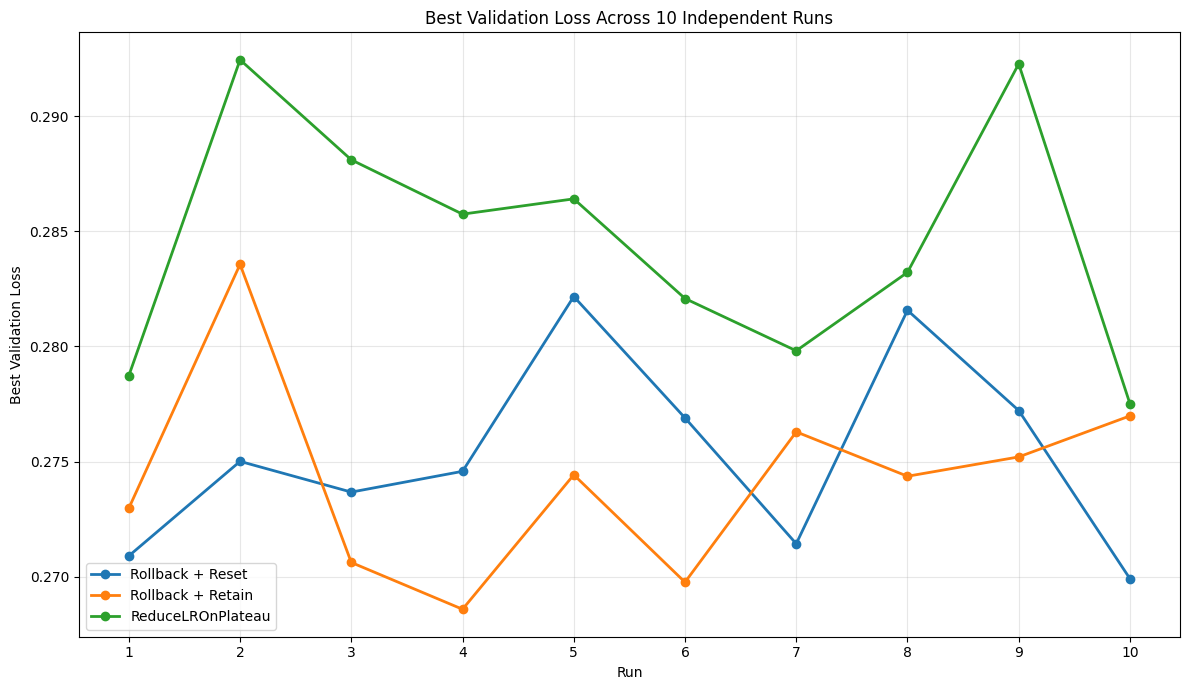

In [44]:
plt.figure(figsize=(12, 7))

for configuration in all_results["configuration"].unique():

    data = all_results[
        all_results["configuration"] == configuration
    ]

    plt.plot(
        data["run"],
        data["best_val_loss"],
        marker="o",
        linewidth=2,
        label=configuration
    )

plt.xlabel("Run")
plt.ylabel("Best Validation Loss")
plt.title("Best Validation Loss Across 10 Independent Runs")

plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/BestValidationLossAcross10IndependentRuns.png')
plt.show()

### Observation

Both rollback strategies achieve lower best validation losses than `ReduceLROnPlateau` across most of the 10 runs. `Rollback + Reset` and `Rollback + Retain` also show similar run-to-run behavior, with `Rollback + Retain` generally producing slightly lower losses.

The results show noticeable variation between independent runs, particularly for `ReduceLROnPlateau`. Therefore, the observed advantage of rollback should be interpreted as an empirical result for this experimental setting rather than a general claim of scheduler superiority.

## 14. Best Epoch Across Independent Runs

The epoch at which the best validation loss was reached is compared across the 10 independent runs.

This provides a view of when each training strategy typically reaches its best observed validation performance.

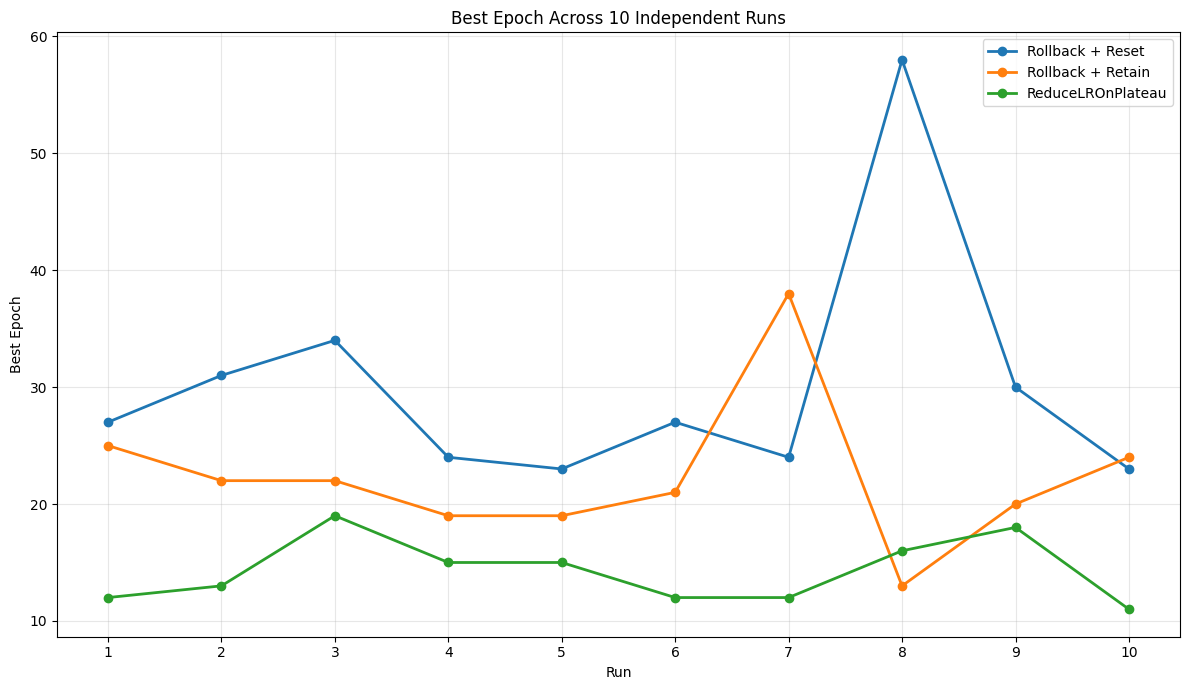

In [46]:
plt.figure(figsize=(12, 7))

for configuration in all_results["configuration"].unique():

    data = all_results[
        all_results["configuration"] == configuration
    ]

    plt.plot(
        data["run"],
        data["best_epoch"],
        marker="o",
        linewidth=2,
        label=configuration
    )

plt.xlabel("Run")
plt.ylabel("Best Epoch")
plt.title("Best Epoch Across 10 Independent Runs")

plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/BestEpochAcross10IndependentRuns.png')
plt.show()

### Observation

The rollback configurations generally reach their best validation loss later than `ReduceLROnPlateau`. `ReduceLROnPlateau` reaches its best epoch between 11 and 19 across the 10 runs, while `Rollback + Reset` and `Rollback + Retain` generally continue improving into later epochs.

The rollback configurations also show greater variation in the epoch at which the best validation loss is reached, reflecting their longer and more varied training trajectories.

## 15. Total Epochs Trained Across Independent Runs

The total number of epochs completed before early stopping is compared across the 10 independent runs.

This helps examine whether the different scheduler strategies lead to substantially different training durations.

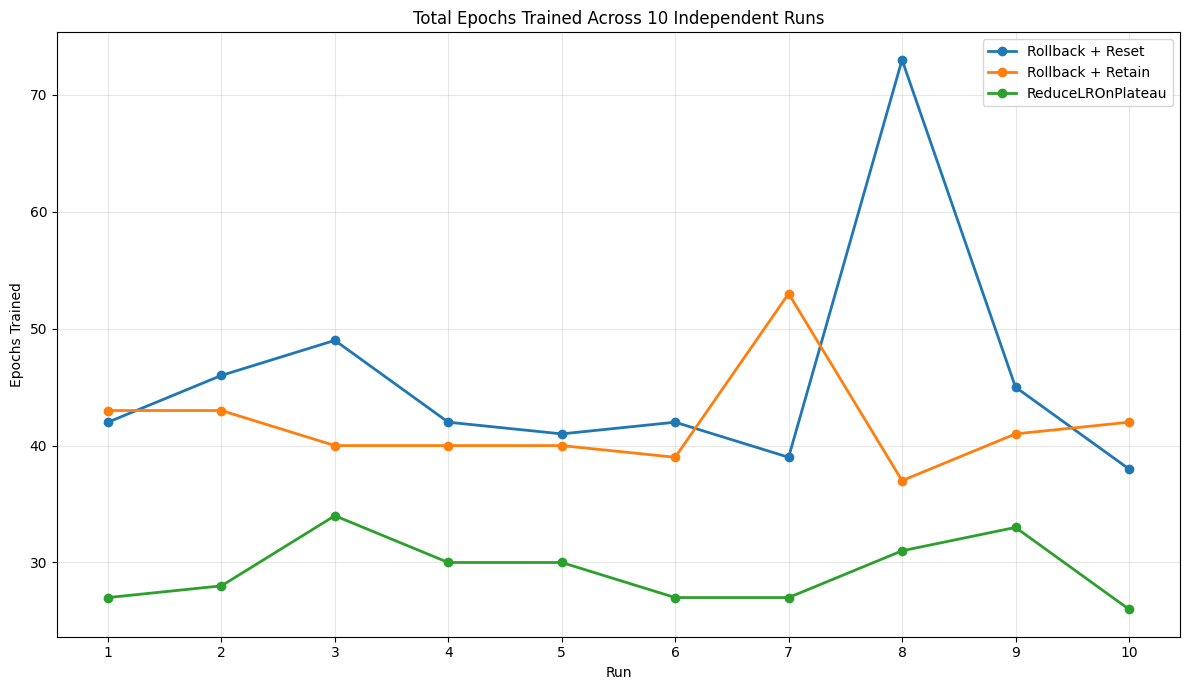

In [47]:
plt.figure(figsize=(12, 7))

for configuration in all_results["configuration"].unique():

    data = all_results[
        all_results["configuration"] == configuration
    ]

    plt.plot(
        data["run"],
        data["epochs_trained"],
        marker="o",
        linewidth=2,
        label=configuration
    )

plt.xlabel("Run")
plt.ylabel("Epochs Trained")
plt.title("Total Epochs Trained Across 10 Independent Runs")

plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/TotalEpochTrainedAcross10IndependentRuns.png')
plt.show()

### Observation

The rollback configurations consistently train for more epochs than `ReduceLROnPlateau`. Across the 10 runs, `ReduceLROnPlateau` trains for 26–34 epochs, compared with 38–73 epochs for `Rollback + Reset` and 37–53 epochs for `Rollback + Retain`.

This shows that rollback achieves its lower validation losses at the cost of longer training. `Rollback + Retain` generally requires fewer epochs than `Rollback + Reset`, indicating a lower computational cost among the two rollback variants.

## 16. Training Time Across Independent Runs

The total training time for each independent run is compared across the three configurations.

This measures the computational cost associated with the different training behaviors observed above.

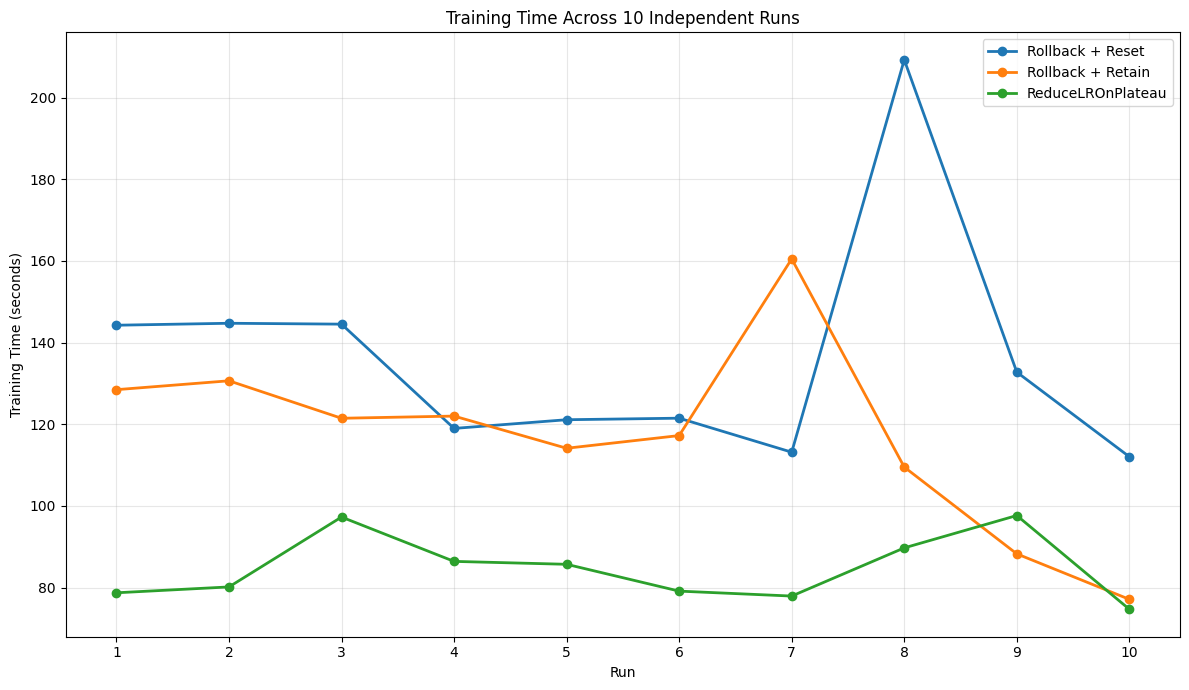

In [48]:
plt.figure(figsize=(12, 7))

for configuration in all_results["configuration"].unique():

    data = all_results[
        all_results["configuration"] == configuration
    ]

    plt.plot(
        data["run"],
        data["training_time_sec"],
        marker="o",
        linewidth=2,
        label=configuration
    )

plt.xlabel("Run")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Across 10 Independent Runs")

plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/TrainingTimeAcross10IndependentRuns.png')
plt.show()

### Observation

The rollback configurations require more training time than `ReduceLROnPlateau` across most of the 10 runs. This follows the same pattern observed in the total epochs trained, since the rollback strategies generally continue optimization for longer.

`Rollback + Retain` is faster on average than `Rollback + Reset`, although both show noticeable run-to-run variation. Overall, the results indicate that the improved validation performance of rollback comes with additional computational cost.

## 17. Rollback Count Across Independent Runs

The number of rollback events triggered during each run is examined for the two rollback configurations.

This provides a direct view of how frequently the rollback mechanism was activated during training.

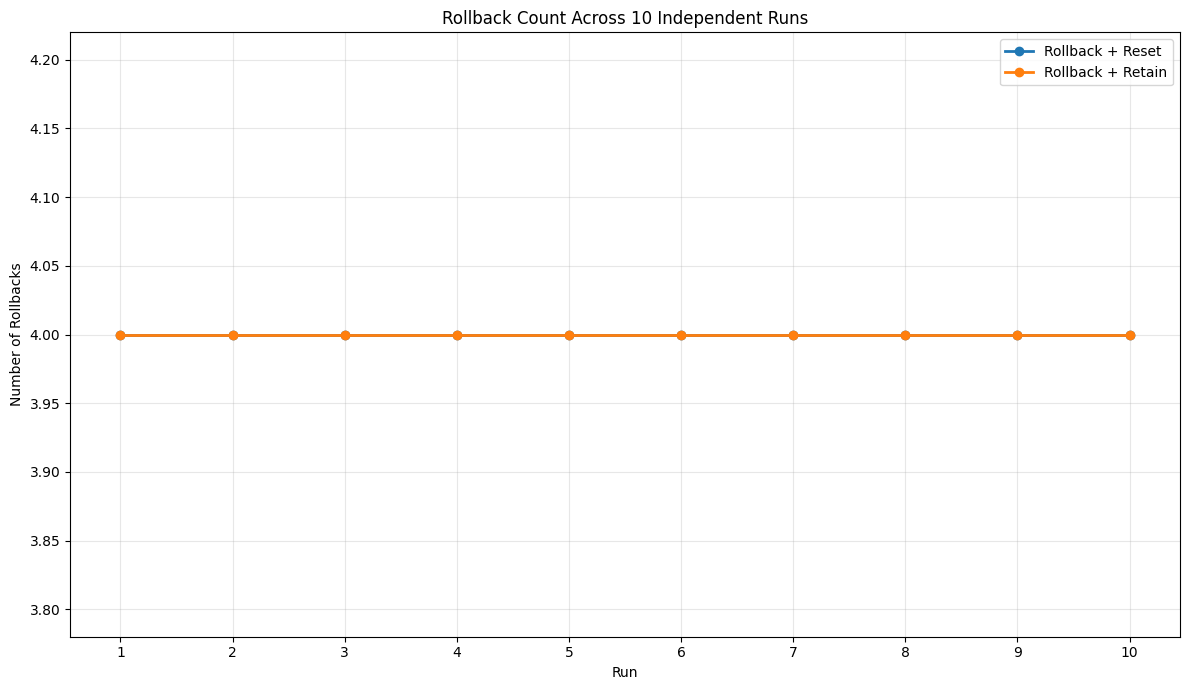

In [49]:
plt.figure(figsize=(12, 7))

for configuration in [
    "Rollback + Reset",
    "Rollback + Retain"
]:

    data = all_results[
        all_results["configuration"] == configuration
    ]

    plt.plot(
        data["run"],
        data["rollback_count"],
        marker="o",
        linewidth=2,
        label=configuration
    )

plt.xlabel("Run")
plt.ylabel("Number of Rollbacks")
plt.title("Rollback Count Across 10 Independent Runs")

plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Distribution of Best Validation Loss

The distribution of the best validation loss across the 10 independent runs is compared between the three training strategies.

This allows the central tendency and variability of the outcomes to be examined together rather than focusing on individual runs.

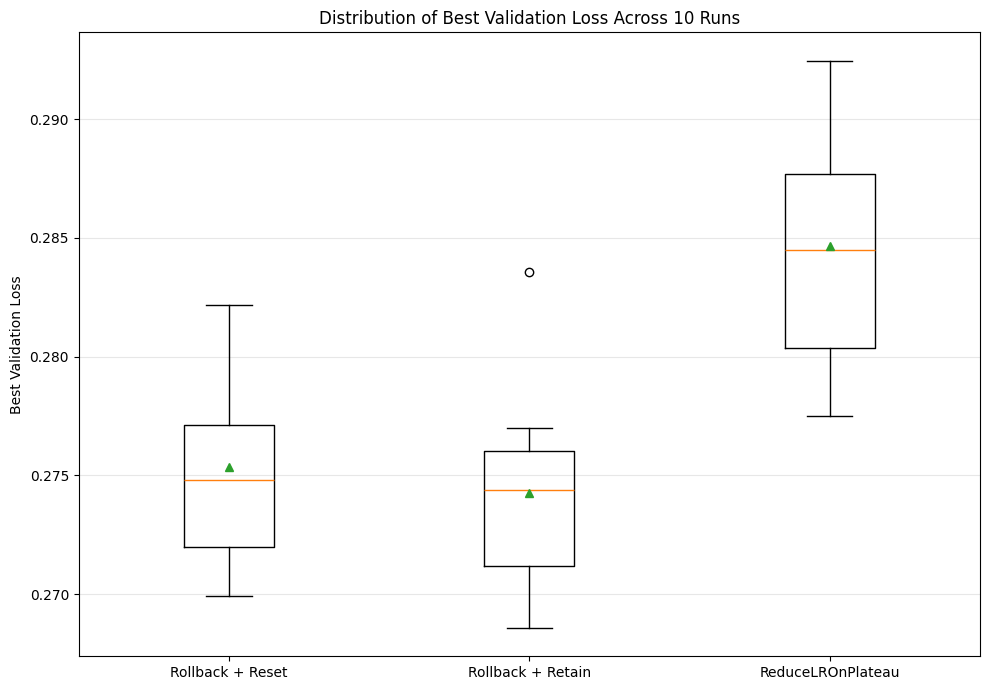

In [50]:
plt.figure(figsize=(10, 7))

data_to_plot = [
    all_results[
        all_results["configuration"] == "Rollback + Reset"
    ]["best_val_loss"],

    all_results[
        all_results["configuration"] == "Rollback + Retain"
    ]["best_val_loss"],

    all_results[
        all_results["configuration"] == "ReduceLROnPlateau"
    ]["best_val_loss"]
]

plt.boxplot(
    data_to_plot,
    tick_labels=[
        "Rollback + Reset",
        "Rollback + Retain",
        "ReduceLROnPlateau"
    ],
    showmeans=True
)

plt.ylabel("Best Validation Loss")
plt.title("Distribution of Best Validation Loss Across 10 Runs")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig('figures/DistributionofBestValidationLossAcross10Runs.png')
plt.show()

### Observation

Both rollback configurations show substantially lower distributions of best validation loss than `ReduceLROnPlateau` across the 10 runs.

`Rollback + Retain` has the lowest median and mean validation loss, while `Rollback + Reset` shows a very similar distribution. The two rollback distributions also overlap considerably, indicating that both optimizer-state strategies produce broadly similar performance in this experiment.

Despite some run-to-run variation and an outlier in the `Rollback + Retain` results, the overall separation from `ReduceLROnPlateau` is consistent across the distributions.

## 18. Learning-Rate Trajectory

The learning-rate trajectory of a representative run from each configuration is examined to visualize how the schedulers modify the learning rate during training.

For the rollback configurations, learning-rate reductions occur together with restoration of the best model state while rollback is available.

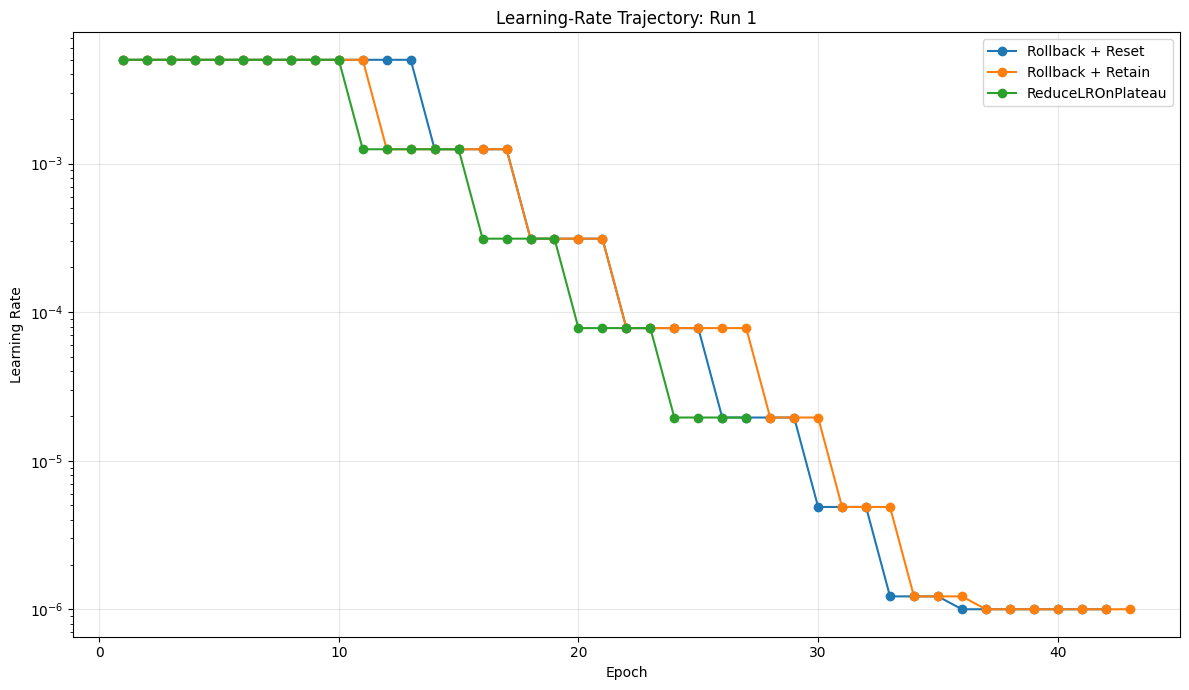

In [53]:
# Representative run: Run 1

run_index = 0

plt.figure(figsize=(12, 7))

plt.plot(
    range(1, len(histories_reset_optimizer[run_index]["lr"]) + 1),
    histories_reset_optimizer[run_index]["lr"],
    marker="o",
    label="Rollback + Reset"
)

plt.plot(
    range(1, len(histories_keep_optimizer[run_index]["lr"]) + 1),
    histories_keep_optimizer[run_index]["lr"],
    marker="o",
    label="Rollback + Retain"
)

plt.plot(
    range(1, len(histories_plateau[run_index]["lr"]) + 1),
    histories_plateau[run_index]["lr"],
    marker="o",
    label="ReduceLROnPlateau"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning-Rate Trajectory: Run 1")

plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/LearningRateTrajectoryRun1.png')
plt.show()

### Observation

The learning-rate trajectories show clearly different scheduling behavior across the three configurations.

`ReduceLROnPlateau` begins reducing the learning rate earlier, while both rollback configurations maintain the initial learning rate for longer before progressively reducing it. The rollback strategies then continue through multiple learning-rate reductions over a longer training trajectory.

This reflects the different optimization dynamics produced by the schedulers: rollback does not simply reduce the learning rate earlier, but restores a previous model state before continuing optimization at the reduced learning rate.

## 19. Learning-Rate Reduction Timing

The epochs at which learning-rate reductions occur are examined across independent runs.

This provides a run-level view of how quickly each scheduler responds to validation-loss plateaus and how its learning-rate schedule evolves over training.

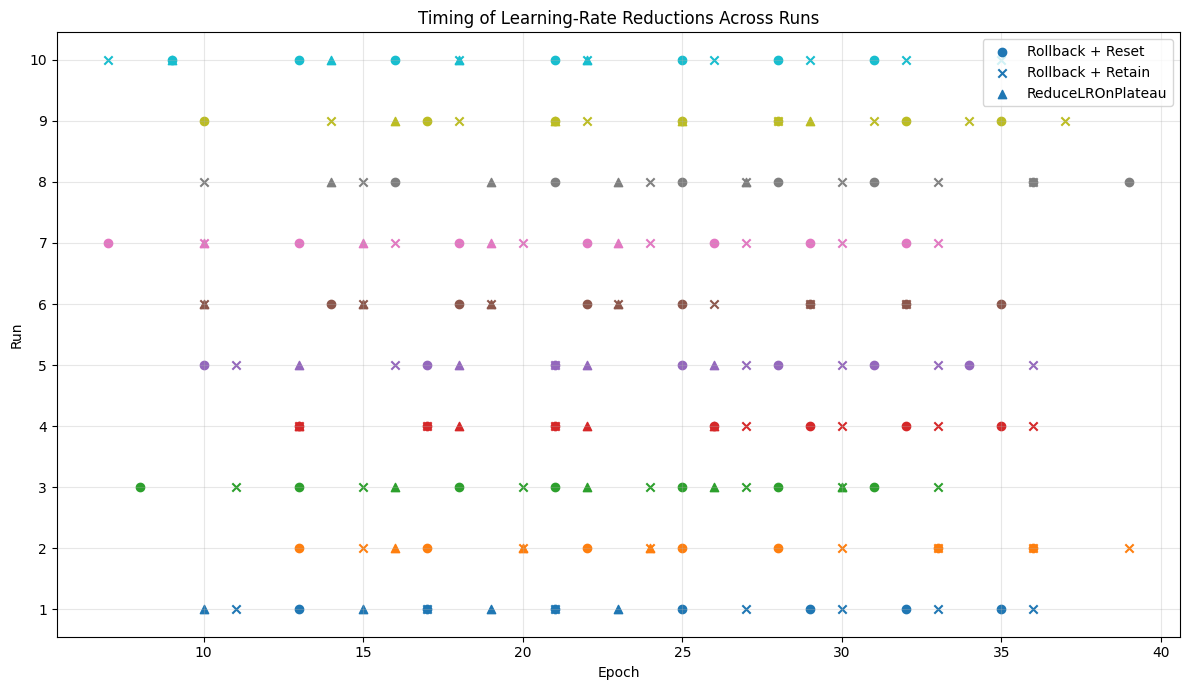

In [55]:
plt.figure(figsize=(12, 7))

for run in range(10):

    epochs = histories_reset_optimizer[run]["lr_change_epochs"]

    plt.scatter(
        epochs,
        [run + 1] * len(epochs),
        label="Rollback + Reset" if run == 0 else None
    )

for run in range(10):

    epochs = histories_keep_optimizer[run]["lr_change_epochs"]

    plt.scatter(
        epochs,
        [run + 1] * len(epochs),
        marker="x",
        label="Rollback + Retain" if run == 0 else None
    )

for run in range(10):

    epochs = histories_plateau[run]["lr_change_epochs"]

    plt.scatter(
        epochs,
        [run + 1] * len(epochs),
        marker="^",
        label="ReduceLROnPlateau" if run == 0 else None
    )

plt.xlabel("Epoch")
plt.ylabel("Run")
plt.title("Timing of Learning-Rate Reductions Across Runs")

plt.yticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/TimingofLearning-RateReductionsAcrossRuns.png')
plt.show()

### Observation

`ReduceLROnPlateau` generally triggers learning-rate reductions earlier than both rollback configurations across the 10 runs.

The rollback configurations begin reducing the learning rate later and continue producing reduction events over a longer portion of training. This is consistent with the longer training trajectories observed for rollback.

The variation in reduction timing across runs also shows that the scheduler response depends on the underlying training trajectory rather than occurring at fixed epochs.

## 20. Best Validation Loss vs Training Time

The relationship between the best validation loss and total training time is examined across the independent runs.

Each point represents one training run. This provides a view of the trade-off between the validation performance achieved and the computational time required.

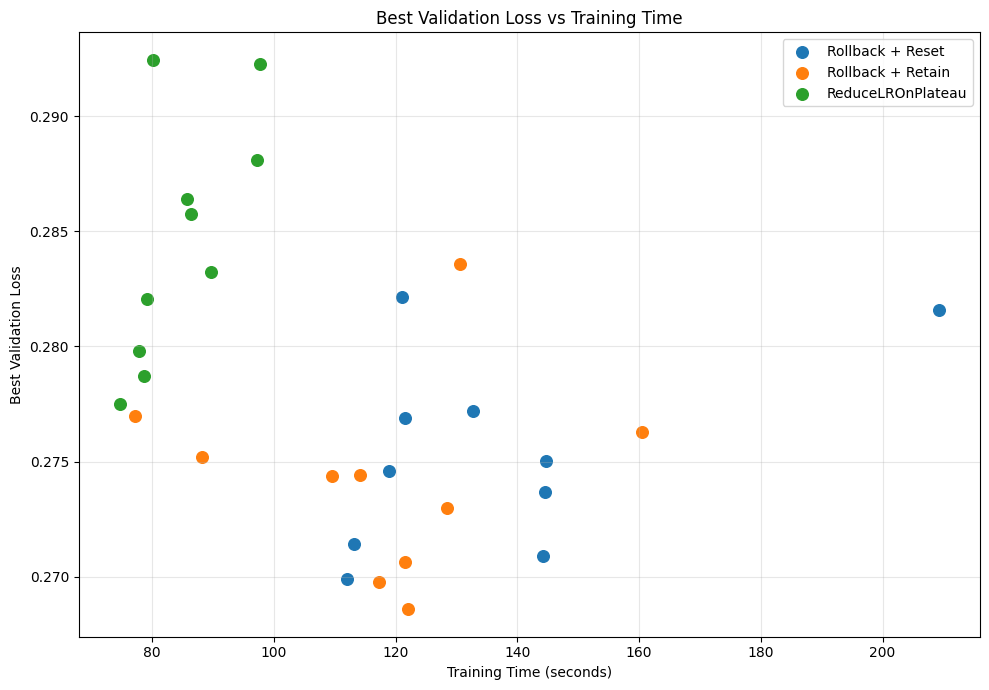

In [56]:
plt.figure(figsize=(10, 7))

for configuration in all_results["configuration"].unique():

    data = all_results[
        all_results["configuration"] == configuration
    ]

    plt.scatter(
        data["training_time_sec"],
        data["best_val_loss"],
        s=70,
        label=configuration
    )

plt.xlabel("Training Time (seconds)")
plt.ylabel("Best Validation Loss")
plt.title("Best Validation Loss vs Training Time")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/BestValidationLossvsTrainingTime.png')
plt.show()

### Observation

The rollback configurations generally achieve lower best validation losses than `ReduceLROnPlateau`, but require more training time to reach those results.

`ReduceLROnPlateau` is concentrated in the lower training-time region but generally at higher validation losses. In contrast, the rollback configurations occupy a higher-cost region while achieving lower losses, showing a clear performance–compute trade-off.

`Rollback + Retain` tends to achieve slightly lower validation losses with lower training time than `Rollback + Reset`, making it the more computationally efficient of the two rollback strategies in these runs.

## 21. Overall Comparison

The mean best validation loss and its standard deviation are compared across the three experimental configurations.

The standard deviation represents the variation observed across the 10 independent runs.

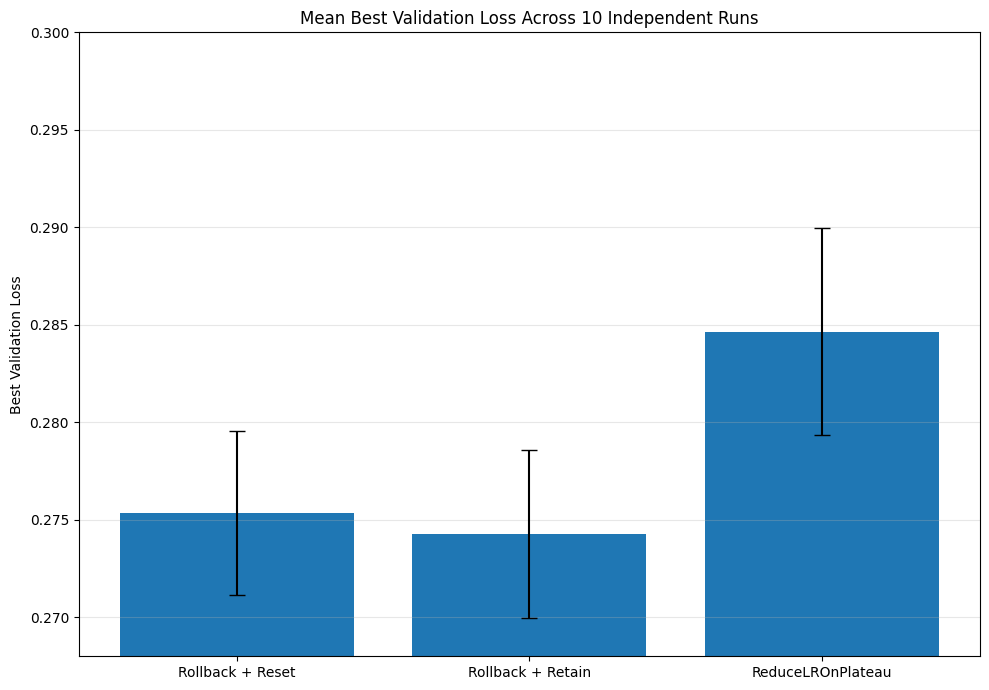

In [59]:
summary_plot = (
    all_results
    .groupby("configuration")["best_val_loss"]
    .agg(["mean", "std"])
    .reindex([
        "Rollback + Reset",
        "Rollback + Retain",
        "ReduceLROnPlateau"
    ])
)

summary_plot


plt.figure(figsize=(10, 7))

plt.bar(
    summary_plot.index,
    summary_plot["mean"],
    yerr=summary_plot["std"],
    capsize=6
)

plt.ylabel("Best Validation Loss")
plt.title("Mean Best Validation Loss Across 10 Independent Runs")

# Focus on the observed range
plt.ylim(0.268, 0.300)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig('figures/MeanBestValidationLossAcross10IndependentRuns.png')
plt.show()

### Observation

Both rollback configurations achieve lower mean best validation loss than `ReduceLROnPlateau` across the 10 independent runs. `Rollback + Retain` achieves the lowest mean loss, followed closely by `Rollback + Reset`, while `ReduceLROnPlateau` has the highest mean loss.

The error bars show noticeable run-to-run variability, but the mean performance of both rollback configurations remains lower than the baseline. This supports the observed performance advantage of rollback in this experimental setting.

## 22. Numerical Comparison

The repeated-run results are summarized using the mean, standard deviation, minimum, and maximum best validation loss.

Training duration and the number of epochs are also compared to quantify the computational cost associated with each strategy.

In [60]:
numerical_comparison = (
    all_results
    .groupby("configuration")
    .agg(
        mean_val_loss=("best_val_loss", "mean"),
        std_val_loss=("best_val_loss", "std"),
        best_val_loss=("best_val_loss", "min"),
        worst_val_loss=("best_val_loss", "max"),
        mean_best_epoch=("best_epoch", "mean"),
        mean_epochs=("epochs_trained", "mean"),
        mean_time_sec=("training_time_sec", "mean"),
    )
    .reindex([
        "Rollback + Reset",
        "Rollback + Retain",
        "ReduceLROnPlateau"
    ])
    .round(4)
)

numerical_comparison

,mean_val_loss,std_val_loss,best_val_loss,worst_val_loss,mean_best_epoch,mean_epochs,mean_time_sec
configuration,,,,,,,
Rollback + Reset,0.2753,0.0042,0.2699,0.2822,30.1,45.7,136.2329
Rollback + Retain,0.2743,0.0043,0.2686,0.2836,22.3,41.8,116.9309
ReduceLROnPlateau,0.2846,0.0053,0.2775,0.2925,14.3,29.3,84.7308


In [61]:
baseline_mean = numerical_comparison.loc[
    "ReduceLROnPlateau",
    "mean_val_loss"
]

numerical_comparison["improvement_vs_plateau_%"] = (
    (baseline_mean - numerical_comparison["mean_val_loss"])
    / baseline_mean
    * 100
)

numerical_comparison.round(4)

,mean_val_loss,std_val_loss,best_val_loss,worst_val_loss,mean_best_epoch,mean_epochs,mean_time_sec,improvement_vs_plateau_%
configuration,,,,,,,,
Rollback + Reset,0.2753,0.0042,0.2699,0.2822,30.1,45.7,136.2329,3.2677
Rollback + Retain,0.2743,0.0043,0.2686,0.2836,22.3,41.8,116.9309,3.6191
ReduceLROnPlateau,0.2846,0.0053,0.2775,0.2925,14.3,29.3,84.7308,0.0000


### Observation

Across the 10 independent runs, both rollback configurations achieved lower mean best validation loss than `ReduceLROnPlateau`.

`Rollback + Reset` achieved a mean best validation loss of approximately **0.2753**, while `Rollback + Retain` achieved approximately **0.2743**, compared with **0.2846** for `ReduceLROnPlateau`. This corresponds to approximately **3.27%** and **3.62%** lower mean validation loss than the baseline, respectively.

However, the rollback configurations required more computation. `Rollback + Reset` trained for an average of **45.7 epochs** and **136.2 seconds**, while `Rollback + Retain` required **41.8 epochs** and **116.9 seconds**, compared with **29.3 epochs** and **84.7 seconds** for `ReduceLROnPlateau`.

Overall, rollback achieved lower validation loss in this experimental setting, at the cost of additional training time.

## 23. What Happened During Rollback?

To examine the behavior of the rollback mechanism directly, the validation loss immediately before and after rollback events is inspected.

A rollback restores the best model state observed so far and reduces the learning rate. The next validation measurement therefore shows the behavior after continuing training from the restored state.

In [70]:
rollback_events = []

rollback_histories = {
    "Rollback + Reset": histories_reset_optimizer,
    "Rollback + Retain": histories_keep_optimizer
}

for configuration, config_histories in rollback_histories.items():

    for run, history in config_histories.items():

        for epoch in history["rollback_epochs"]:

            before_loss = history["val_loss"][epoch]

            best_before = min(
                history["val_loss"][:epoch]
            )

            after_loss = (
                history["val_loss"][epoch + 1]
                if epoch + 1 < len(history["val_loss"])
                else np.nan
            )

            rollback_events.append({
                "configuration": configuration,
                "run": run + 1,
                "rollback_epoch": epoch + 1,
                "best_loss_before_rollback": best_before,
                "loss_at_rollback": before_loss,
                "loss_next_epoch": after_loss,
                "improvement_next_epoch": (
                    before_loss - after_loss
                    if not np.isnan(after_loss)
                    else np.nan
                )
            })

rollback_events_df = pd.DataFrame(rollback_events)

rollback_events_df.to_csv("results/rollback_events.csv",
    index=False
)

In [71]:
rollback_events_summary = (
    rollback_events_df
    .groupby("configuration")
    .agg(
        rollback_events=("run", "count"),
        mean_loss_after_rollback=("loss_next_epoch", "mean"),
        mean_improvement_next_epoch=(
            "improvement_next_epoch",
            "mean"
        )
    )
    .round(6)
)

rollback_events_summary

,rollback_events,mean_loss_after_rollback,mean_improvement_next_epoch
configuration,,,
Rollback + Reset,40,0.278445,0.014037
Rollback + Retain,40,0.276561,0.014482


## 24. Optimizer Reset vs Retain

The two rollback configurations differ only in how the optimizer state is handled after restoring the best model parameters.

- **Reset:** model parameters are restored and the AdamW optimizer state is cleared.
- **Retain:** model parameters are restored while the stored optimizer state is retained.

The results are compared to examine whether this distinction produced a meaningful difference in the observed training behavior.

### Observation

`Rollback + Retain` achieved a slightly lower mean best validation loss (**0.2743**) than `Rollback + Reset` (**0.2753**) across the 10 runs. It also required fewer epochs on average (**41.8 vs 45.7**) and less training time (**116.9 s vs 136.2 s**).

However, the difference in validation loss is small, and the distributions of the two configurations overlap substantially. In these experiments, retaining the optimizer state therefore showed a modest advantage in both validation performance and computational cost, but the results do not establish that retaining the optimizer state is generally superior.

In [72]:
optimizer_comparison = (
    all_results[
        all_results["configuration"].isin([
            "Rollback + Reset",
            "Rollback + Retain"
        ])
    ]
    .groupby("configuration")
    .agg(
        mean_val_loss=("best_val_loss", "mean"),
        std_val_loss=("best_val_loss", "std"),
        best_val_loss=("best_val_loss", "min"),
        mean_best_epoch=("best_epoch", "mean"),
        mean_epochs=("epochs_trained", "mean"),
        mean_time_sec=("training_time_sec", "mean")
    )
    .round(4)
)

optimizer_comparison

,mean_val_loss,std_val_loss,best_val_loss,mean_best_epoch,mean_epochs,mean_time_sec
configuration,,,,,,
Rollback + Reset,0.2753,0.0042,0.2699,30.1,45.7,136.2329
Rollback + Retain,0.2743,0.0043,0.2686,22.3,41.8,116.9309


### Observation

The two rollback variants produced broadly similar results across the 10 runs.

`Rollback + Retain` achieved a slightly lower mean best validation loss than `Rollback + Reset` (**0.2743 vs 0.2753**). It also required fewer epochs (**41.8 vs 45.7**) and less training time (**116.9 s vs 136.2 s**) on average.

Within this experiment, retaining the optimizer state showed a small advantage in both validation performance and computational cost. However, the differences are modest and are based on 10 independent runs, so they should not be interpreted as a general conclusion about optimizer-state handling.

## 25. Limitations

Several limitations should be considered when interpreting these results:

1. **Limited number of runs**  
   Each configuration was evaluated using 10 independent runs. This provides evidence of run-to-run behavior but is not a large statistical sample.

2. **Single dataset and architecture**  
   The experiment uses one dataset and one neural-network architecture. The observed behavior may not generalize to other tasks, datasets, or architectures.

3. **Scheduler hyperparameters**  
   The comparison uses one selected set of patience, learning-rate factor, minimum learning rate, and rollback limits. Different choices may produce different outcomes.

4. **Independent stochastic runs**  
   The runs use fresh model initialization and natural training stochasticity. The configurations are therefore not paired using identical random seeds.

5. **Different rollback mechanisms**  
   The two rollback variants differ in their handling of AdamW optimizer state. The experiment evaluates the observed difference between resetting and retaining this state, but does not isolate the effect of other possible implementation choices.

6. **Computational budget**  
   The rollback configurations train for more epochs on average than `ReduceLROnPlateau`, resulting in greater computational cost. The comparison therefore reflects a trade-off between validation performance and computation rather than performance under an identical computational budget.

7. **Exploratory implementation**  
   `RollbackLROnPlateau` is a custom implementation created for this investigation. The experiment evaluates its observed behavior rather than establishing a theoretically optimal optimization strategy.

8. **Limited task diversity**  
   The main investigation is performed on Fashion-MNIST. Observations from a separate heavy-machinery regression task showed that rollback and `ReduceLROnPlateau` can perform similarly, suggesting that the observed advantage may depend on the optimization dynamics of the particular problem.

## 26. Conclusion

This investigation explored a simple modification to plateau-based learning-rate scheduling: instead of only reducing the learning rate when validation loss stops improving, the model is first restored to its best previously observed state.

Across 10 independent runs per configuration, both rollback strategies achieved lower mean best validation loss than the `ReduceLROnPlateau` baseline under the experimental settings used here. `Rollback + Retain` achieved the lowest mean best validation loss, while also requiring less training time than `Rollback + Reset`.

The rollback events also showed a consistent short-term effect in these experiments. Across 40 rollback events for each strategy, the validation loss improved by approximately 0.014 on average in the following epoch. However, this immediate improvement does not imply that every rollback leads directly to the eventual best validation loss.

The improved validation performance came at the cost of additional computation, with both rollback configurations requiring more epochs and training time than the baseline. The results therefore suggest a trade-off between optimization performance and computational cost.

The separate heavy-machinery regression experiment also showed that rollback does not necessarily provide an advantage over `ReduceLROnPlateau`, with both approaches achieving similar validation performance. This suggests that the effectiveness of rollback may depend on the optimization dynamics of the particular problem rather than being a universally superior scheduling strategy.

Overall, the experiments support the hypothesis that restoring a previous low-loss state before reducing the learning rate can produce different and potentially favorable training trajectories. The main outcome of this investigation is therefore not a claim of scheduler superiority, but an empirical observation of when and how rollback changes optimization behavior and the questions this raises for further controlled experiments.